# **Modèles d'IA** **- Détection et Classification du Harcèlement**


## **1.  Préparation générale**

Objectfis:


*   Identifier les messages haineux ou non
*   Classifier les messages haineux en 6 catégories : Homophobie, Islamophobie, Racisme, Sexisme, Validisme, Xénophobie



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Chargement
train = pd.read_csv('/content/Base_Train2.csv')
test  = pd.read_csv('/content/Base_Test2.csv')

print(f'Train : {train.shape[0]} lignes | Test : {test.shape[0]} lignes')
print(f'Colonnes : {train.columns.tolist()}')
train.head(3)

Train : 2400 lignes | Test : 240 lignes
Colonnes : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']


,Identifiant,Texte,Traduction,Types,Categories
0,1,Why is it that all gay people are repulsive?,Pourquoi tous les homosexuels sont-ils considé...,Haineux,Homophobie
1,2,Gay people are a c a n c e r.,Les homosexuels sont un cancer.,Haineux,Homophobie
2,3,Deaht to all gay people.,Mort à tous les homosexuels.,Haineux,Homophobie


## **2.  Régression Logistique**

In [ ]:
# =========================================================
# PROJET ML — HARCELEMENT
# - 2.1 Régression logistique binaire
# - 2.2 Régression logistique multi-classe
# - Validation croisée
# - Test réel + export CSV
# =========================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =========================================================
# 1. CHARGEMENT DES DONNÉES
# =========================================================
TRAIN_PATH = "Base_Train2.csv"
TEST_PATH  = "Base_Test2.csv"

def read_csv_safely(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    try:
        return pd.read_csv(path)
    except:
        return pd.read_csv(path, encoding="latin-1")

train_df = read_csv_safely(TRAIN_PATH)
test_df  = read_csv_safely(TEST_PATH)

train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

TEXT_COL = "Texte"

print("Colonnes :", train_df.columns.tolist())

# =========================================================
# 2. ===== 2.1 RÉGRESSION LOGISTIQUE BINAIRE =====
# =========================================================
print("\n" + "="*60)
print("2.1 RÉGRESSION LOGISTIQUE BINAIRE")
print("="*60)

train_bin = train_df.dropna(subset=[TEXT_COL, "Types"]).copy()
test_bin  = test_df.dropna(subset=[TEXT_COL, "Types"]).copy()

X_train_bin = train_bin[TEXT_COL].astype(str)
y_train_bin = train_bin["Types"]

X_test_bin = test_bin[TEXT_COL].astype(str)
y_test_bin = test_bin["Types"]

model_bin = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

model_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = model_bin.predict(X_test_bin)

print("\n--- RÉSULTATS BINAIRE (TEST) ---")
print(classification_report(y_test_bin, y_pred_bin))

print("Matrice de confusion :")
print(confusion_matrix(y_test_bin, y_pred_bin))

# =========================================================
# 3. ===== 2.2 RÉGRESSION LOGISTIQUE MULTICLASSE =====
# =========================================================
print("\n" + "="*60)
print("2.2 RÉGRESSION LOGISTIQUE MULTICLASSE")
print("="*60)

train_cat = train_df.dropna(subset=[TEXT_COL, "Categories"]).copy()

X = train_cat[TEXT_COL].astype(str)
y = train_cat["Categories"]

# SPLIT 80/20
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {len(X_train)} | Validation: {len(X_valid)}")

model_cat = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000))
])

# =========================================================
# 4. VALIDATION CROISÉE
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nValidation croisée...")
cv_scores = cross_val_score(model_cat, X_train, y_train, cv=cv, scoring="f1_macro")
print("F1 moyen:", round(cv_scores.mean(),4))

# =========================================================
# 5. VALIDATION 20%
# =========================================================
model_cat.fit(X_train, y_train)
y_pred = model_cat.predict(X_valid)

print("\n--- RÉSULTATS VALIDATION 20% ---")
print(classification_report(y_valid, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_valid, y_pred))

# =========================================================
# 6. TEST FINAL (BASE TEST)
# =========================================================
print("\n--- TEST FINAL (BASE_TEST2) ---")

test_cat = test_df.dropna(subset=[TEXT_COL, "Categories"]).copy()

y_test_cat = test_cat["Categories"]
X_test_cat = test_cat[TEXT_COL].astype(str)

y_pred_test = model_cat.predict(X_test_cat)

print(classification_report(y_test_cat, y_pred_test))

# =========================================================
# 7. EXPORT CSV
# =========================================================
model_cat.fit(X, y)

test_df["prediction"] = model_cat.predict(test_df[TEXT_COL].astype(str))

test_df.to_csv("predictions_test_final.csv", index=False, encoding="utf-8-sig")

print("\nFichier généré : predictions_test_final.csv")

Colonnes : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']

2.1 RÉGRESSION LOGISTIQUE BINAIRE

--- RÉSULTATS BINAIRE (TEST) ---
              precision    recall  f1-score   support

     Haineux       0.93      0.84      0.88       120
 Non Haineux       0.85      0.93      0.89       120

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240

Matrice de confusion :
[[101  19]
 [  8 112]]

2.2 RÉGRESSION LOGISTIQUE MULTICLASSE

Train: 960 | Validation: 240

Validation croisée...
F1 moyen: 0.9028

--- RÉSULTATS VALIDATION 20% ---
              precision    recall  f1-score   support

  Homophobie       0.97      0.90      0.94        40
Islamophobie       0.86      0.90      0.88        40
     Racisme       0.97      0.90      0.94        40
     Sexisme       0.78      0.95      0.85        40
   Validisme       0.97      0.90      0.94        40
  Xénophobie     

**2.1 Régression logistique binaire (Haineux / Non Haineux)**

Dans cette première étape, un modèle de régression logistique est utilisé afin de distinguer les textes haineux des textes non haineux, à partir de la colonne Types.

Les textes sont transformés en vecteurs numériques grâce à la méthode TF-IDF, qui permet de représenter l’importance des mots dans chaque document. Le modèle est ensuite entraîné sur ces données pour apprendre à différencier les deux classes.

Les performances obtenues sur la base de test sont les suivantes :
	•	Accuracy : 89%
	•	F1-score : 0.89

Ces résultats montrent que le modèle est capable de détecter efficacement les contenus haineux. L’analyse détaillée indique un bon équilibre entre précision et rappel pour les deux classes. Par exemple, la classe Haineux atteint un F1-score de 0.88, tandis que la classe Non Haineux atteint 0.89.

La matrice de confusion confirme ces performances, avec une majorité de prédictions correctes et un nombre limité d’erreurs. Cela montre que le modèle généralise correctement sur des données non vues.

Ainsi, la régression logistique binaire constitue une première étape fiable pour filtrer les contenus haineux avant une analyse plus fine.


**2.2 Régression logistique pour les sous-catégories**

Dans une seconde étape, un modèle de régression logistique multi-classe est utilisé afin de classifier les textes haineux selon leur catégorie : homophobie, islamophobie, racisme, sexisme, validisme et xénophobie.

Le modèle est évalué à l’aide d’une validation croisée (5-fold), puis sur un jeu de validation (20%) et enfin sur une base de test indépendante.

Les résultats obtenus sont les suivants :
	•	Validation croisée (train 80%) : F1 moyen = 0.90
	•	Validation 20% : Accuracy = 91%, F1 = 0.91
	•	Test final : Accuracy = 91%, F1 = 0.91

Ces résultats montrent que le modèle est très performant et stable, avec une bonne capacité de généralisation. La cohérence entre les scores de validation et de test indique qu’il n’y a pas de sur-apprentissage.

L’analyse par catégorie montre également de très bonnes performances, avec certaines classes atteignant des F1-scores élevés :
	•	Validisme : 0.97
	•	Homophobie : 0.95
	•	Xénophobie : 0.95

Certaines catégories comme le racisme présentent des scores légèrement plus faibles, ce qui peut s’expliquer par la similarité linguistique entre certaines formes de discours haineux.

Les modèles de régression logistique permettent d’obtenir des résultats très satisfaisants, avec des performances élevées en classification binaire et multi-classe.

L’approche en deux étapes (détection puis catégorisation) permet de structurer efficacement le problème. De plus, la stabilité des résultats entre validation et test confirme la robustesse du modèle.

Ces performances montrent que des modèles simples comme la régression logistique peuvent être très efficaces pour des tâches de classification de texte, tout en restant rapides et interprétables.

##**3.  TF-IDF + Régression Logistique**


In [ ]:
from google.colab import files
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

uploaded = files.upload()

train = pd.read_csv('Base_Train2.csv')
test = pd.read_csv('Base_Test2.csv')

X_train = train['Texte']
X_test = test['Texte']

y_train_type = train['Types']
y_test_type = test['Types']

y_train_cat = train['Categories'].fillna('Non Haineux')
y_test_cat = test['Categories'].fillna('Non Haineux')

# TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Modèle 1 : Haineux vs Non Haineux
clf_type = LogisticRegression(max_iter=1000, random_state=42)
clf_type.fit(X_train_tfidf, y_train_type)
y_pred_type = clf_type.predict(X_test_tfidf)

print("CLASSIFICATION BINAIRE : Haineux vs Non Haineux")
print(classification_report(y_test_type, y_pred_type))

# Modèle 2 : Les 6 catégories + Non Haineux
clf_cat = LogisticRegression(max_iter=1000, random_state=42)
clf_cat.fit(X_train_tfidf, y_train_cat)
y_pred_cat = clf_cat.predict(X_test_tfidf)

print("CLASSIFICATION MULTICLASSE : Catégories de harcèlement")
print(classification_report(y_test_cat, y_pred_cat))


results = pd.DataFrame({
    'Texte': test['Texte'].values,
    'Type_Réel': y_test_type.values,
    'Type_Prédit': y_pred_type,
    'Categorie_Réelle': y_test_cat.values,
    'Categorie_Prédite': y_pred_cat
})
results.to_csv('Resultats_TFIDF_BaseTest.csv', index=False, encoding='utf-8-sig')
print("Fichier exporté !")

Saving Base_Test2.csv to Base_Test2 (2).csv
Saving Base_Train2.csv to Base_Train2 (3).csv
CLASSIFICATION BINAIRE : Haineux vs Non Haineux
              precision    recall  f1-score   support

     Haineux       0.93      0.84      0.88       120
 Non Haineux       0.85      0.93      0.89       120

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240

CLASSIFICATION MULTICLASSE : Catégories de harcèlement
              precision    recall  f1-score   support

  Homophobie       1.00      0.90      0.95        20
Islamophobie       1.00      0.75      0.86        20
 Non Haineux       0.82      0.98      0.89       120
     Racisme       1.00      0.55      0.71        20
     Sexisme       0.86      0.60      0.71        20
   Validisme       1.00      0.95      0.97        20
  Xénophobie       1.00      0.95      0.97        20

    accuracy                           0.88   

Expérience 1 — Entraînement sur Base_Train2, test sur Base_Test2

Pour cette première expérience, nous avons entraîné le modèle sur l'intégralité de notre Base_Train2 qui contient 2400 textes — 1200 haineux répartis en 200 textes par catégorie, et 1200 non haineux — puis nous l'avons évalué sur notre Base_Test2 qui contient 240 textes totalement indépendants, soit 20 textes par catégorie haineuse et 120 non haineux. Cette séparation stricte entre les deux bases avait été établie dès la semaine 3 de notre projet, précisément pour pouvoir réaliser cette évaluation dans des conditions réalistes.

En classification binaire, le modèle atteint 89% de précision globale. Concrètement, sur 240 textes de la Base_Test2, il s'est trompé sur environ 26 textes. La precision pour la classe "Haineux" est de 0.93, ce qui signifie que lorsque le modèle désigne un texte comme haineux, il a raison 93% du temps. En revanche le recall est de 0.85, ce qui veut dire qu'il passe à côté de 15% des textes réellement haineux. Ces textes ratés correspondent probablement à des messages dont le langage haineux est plus implicite ou détourné, par exemple des textes formulés sous forme de question comme "Why is it that all gay people are repulsive?" qui peuvent être interprétés différemment selon le contexte.
En classification multiclasse, la précision globale est de 88%. Les résultats varient fortement selon les catégories de notre base. Le Validisme et la Xénophobie obtiennent les meilleurs scores avec un F1 de 0.97, ce qui s'explique par le fait que dans notre base d'entraînement, ces catégories sont associées à un vocabulaire très ciblé et peu ambigu comme "disabled", "immigrants" ou "wetback". L'Homophobie suit avec un F1 de 0.95 grâce à des termes très spécifiques comme "faggot" ou "queer".

Le Racisme en revanche chute à un F1 de 0.71 avec un recall de seulement 0.55, ce qui signifie que le modèle rate presque la moitié des textes racistes de la Base_Test2. C'est un résultat surprenant car lors de nos tests internes sur Base_Train2, le Racisme était bien détecté. Cela suggère que les 20 textes racistes de notre Base_Test2 utilisent un vocabulaire ou des formulations différentes de ceux présents dans les 200 textes racistes de Base_Train2. C'est une limite directement liée à la construction de nos bases : si les deux bases ne couvrent pas les mêmes expressions du racisme, le modèle ne peut pas généraliser correctement.

Le Sexisme reste difficile à détecter avec un F1 de 0.71. Cela correspond à ce que nous observions déjà lors des semaines précédentes. Le discours sexiste dans notre base utilise des mots comme "women", "female" ou "bitch" qui peuvent apparaître dans des contextes très différents, ce qui brouille la frontière entre haineux et non haineux pour le modèle.

Un point important à souligner concerne les faux négatifs sur la classe "Non Haineux" : 18% des textes classés comme non haineux sont en réalité haineux. Dans le cadre d'un outil réel de modération de contenu, ces erreurs seraient particulièrement problématiques car elles correspondraient à des messages haineux qui passeraient inaperçus et ne seraient pas signalés.

In [ ]:
from google.colab import files
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

uploaded = files.upload()

train = pd.read_csv('Base_Train2.csv')

X = train['Texte']
y_type = train['Types']
y_cat = train['Categories'].fillna('Non Haineux')

random_states = [42, 1, 123]
accuracies_type = []
accuracies_cat = []

for i, rs in enumerate(random_states):
    print(f"\n{'='*60}")
    print(f"TOUR {i+1} (random_state={rs})")
    print('='*60)

    X_train, X_test, y_train_type, y_test_type, y_train_cat, y_test_cat = train_test_split(
        X, y_type, y_cat, test_size=0.2, random_state=rs, stratify=y_type
    )

    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english',
                                  max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Binaire
    clf_type = LogisticRegression(max_iter=1000, random_state=rs)
    clf_type.fit(X_train_tfidf, y_train_type)
    y_pred_type = clf_type.predict(X_test_tfidf)
    print("CLASSIFICATION BINAIRE : Haineux vs Non Haineux")
    print(classification_report(y_test_type, y_pred_type))

    # Multiclasse
    clf_cat = LogisticRegression(max_iter=1000, random_state=rs)
    clf_cat.fit(X_train_tfidf, y_train_cat)
    y_pred_cat = clf_cat.predict(X_test_tfidf)
    print("CLASSIFICATION MULTICLASSE : Catégories de harcèlement")
    print(classification_report(y_test_cat, y_pred_cat))

    # Sauvegarde des accuracies
    acc_type = np.mean(y_pred_type == y_test_type)
    acc_cat = np.mean(y_pred_cat == y_test_cat)
    accuracies_type.append(acc_type)
    accuracies_cat.append(acc_cat)

print(f"\n{'='*60}")
print("RESULTATS MOYENS SUR LES 3 TOURS")
print('='*60)
print(f"Binaire    : {np.mean(accuracies_type)*100:.2f}%")
print(f"Multiclasse: {np.mean(accuracies_cat)*100:.2f}%")

Saving Base_Train2.csv to Base_Train2 (4).csv

TOUR 1 (random_state=42)
CLASSIFICATION BINAIRE : Haineux vs Non Haineux
              precision    recall  f1-score   support

     Haineux       0.98      0.98      0.98       240
 Non Haineux       0.98      0.98      0.98       240

    accuracy                           0.98       480
   macro avg       0.98      0.98      0.98       480
weighted avg       0.98      0.98      0.98       480

CLASSIFICATION MULTICLASSE : Catégories de harcèlement
              precision    recall  f1-score   support

  Homophobie       1.00      0.79      0.89        34
Islamophobie       1.00      0.95      0.97        37
 Non Haineux       0.91      1.00      0.95       240
     Racisme       1.00      0.89      0.94        36
     Sexisme       0.82      0.80      0.81        46
   Validisme       1.00      0.85      0.92        40
  Xénophobie       1.00      0.89      0.94        47

    accuracy                           0.93       480
   macro a

 3 entraînements répétitifs avec splits différents sur Base_Train2

L'objectif de cette deuxième expérience était de vérifier que les résultats obtenus sur notre Base_Train2 ne dépendent pas du hasard lié à un découpage particulier. En effet, lors d'un seul split 80/20, il est possible que certains textes difficiles tombent par chance dans la partie test ou dans la partie train, ce qui fausserait les performances mesurées. En répétant l'opération trois fois avec des graines aléatoires différentes (42, 1 et 123), on s'assure que les résultats sont reproductibles et stables indépendamment du découpage.
Les résultats confirment cette stabilité. En binaire, les trois tours donnent 98%, 97% et 96%, soit une moyenne de 97.36% avec une variation de seulement 2 points entre le meilleur et le moins bon tour. En multiclasse, les trois tours donnent 93%, 90% et 90%, soit une moyenne de 91.11%. Ces variations très faibles prouvent que notre modèle TF-IDF apprend des patterns linguistiques généralisables dans notre corpus et non des spécificités propres à un découpage particulier.

On remarque cependant que ces scores sont systématiquement meilleurs que ceux obtenus dans l'expérience 1 sur la Base_Test2. Cela s'explique par le fait que dans les splits internes, les textes de test sont issus de la même base que les textes d'entraînement : ils partagent le même style, la même source et le même vocabulaire général. La Base_Test2 en revanche a été construite séparément dès le début du projet, ce qui en fait un jeu de données vraiment indépendant et donc plus difficile à prédire. Cette différence entre les deux expériences est normale et attendue, et illustre bien l'importance d'avoir une base de test véritablement séparée comme nous l'avons fait depuis la semaine 3.

Le Sexisme reste la catégorie la plus instable entre les trois tours avec un F1 variant de 0.76 à 0.82. Cette instabilité relative confirme que la difficulté à détecter le sexisme n'est pas liée au découpage des données mais bien à la nature intrinsèquement ambiguë de ce type de discours dans notre base. Quelle que soit la façon dont on découpe les données, le modèle peine à généraliser sur cette catégorie.

Ce que ces deux expériences nous apprennent :

En combinant les résultats des deux expériences, on peut tirer plusieurs conclusions sur notre système de détection. Le TF-IDF est une méthode efficace et stable pour notre problématique, avec des performances moyennes de 97% en binaire et 91% en multiclasse sur nos données internes. Sur notre Base_Test2 indépendante les performances descendent à 89% et 88%, ce qui reste satisfaisant et représente les performances réalistes de notre système. Les catégories les plus fiables sont le Validisme, la Xénophobie et l'Homophobie, tandis que le Sexisme et le Racisme sur données nouvelles représentent les principales limites actuelles de notre modèle, qui pourront être adressées lors des prochaines étapes du projet.

## **4.  Bag of Words + Régression logistique**



Pourquoi le Bag of Words ? Les visualisations exploratoires trouvables dans le pdf "visu_final" sur notre Github ont montré que les messages haineux et neutres possèdent des vocabulaires radicalement différents. Les nuages de mots et les graphiques de fréquences ont révélé que chaque catégorie de harcèlement possède ses propres marqueurs lexicaux dominants ("gay" pour l'Homophobie, "muslims" pour l'Islamophobie, "black" pour le Racisme, etc.). Cette séparabilité lexicale forte justifie l'utilisation d'un modèle Bag of Words : transformer chaque message en vecteur de fréquences de mots suffit à capturer l'information discriminante. Le Bag of Words est le modèle de référence (baseline) : simple, rapide, interprétable. Si ce modèle simple obtient déjà de bonnes performances, cela confirme que le signal textuel est suffisamment fort pour être exploité par des approches classiques.


### Démarche d'entraînement progressif
Le modèle a été entraîné 6 fois sur la base Train avec des améliorations successives. À chaque version, on mesure les performances via une validation croisée à 5 folds : la base Train est divisée en 5 parties, le modèle est entraîné sur 4 et testé sur la 5ème, répété 5 fois. La moyenne des 5 scores donne une estimation fiable sans jamais toucher à la base Test.

In [ ]:
# MODÈLE BAG OF WORDS sur la détection du harcèlement
# Base Train : entraînement + amélioration progressive
# Base Test  : évaluation finale sur données jamais vues

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# etape1 — cest le chargement des donnees
train = pd.read_csv("/content/Base_Train2.csv", encoding="utf-8")
test  = pd.read_csv("/content/Base_Test2.csv",  encoding="utf-8")

train.columns = train.columns.str.strip()
test.columns  = test.columns.str.strip()

print("="*60)
print("BASE TRAIN")
print(f"  Nombre de messages : {len(train)}")
print(train["Types"].value_counts())
print("\nBASE TEST")
print(f"  Nombre de messages : {len(test)}")
print(test["Types"].value_counts())

# etape 2
# tache binaire : 1 = Haineux, 0 = Non Haineux
train["label"] = train["Types"].apply(lambda x: 1 if x == "Haineux" else 0)
test["label"]  = test["Types"].apply(lambda x: 1 if x == "Haineux" else 0)

X_train = train["Texte"]
y_train = train["label"]
X_test  = test["Texte"]
y_test  = test["label"]

BASE TRAIN
  Nombre de messages : 2400
Types
Haineux        1200
Non Haineux    1200
Name: count, dtype: int64

BASE TEST
  Nombre de messages : 240
Types
Haineux        120
Non Haineux    120
Name: count, dtype: int64


In [ ]:
# etape 3 :
# on entraine plusieurs versions du modèle, chacune un peu meilleure que la précédente mais que sur la base Train.
# puis on mesure la performance avec une validation croisée
# (on divise le train en 5 parties et on teste sur chacune).

print("\n" + "="*60)
print("enrainement progressif sur la base train")
print("="*60)

resultats = []

# versuon 1 : bag of words basique
# juste les mots individuel et pas de nettoyage
print("\nVersion 1 — BOW basique (mots seuls et sans nettoyage)...")
pipeline_v1 = Pipeline([
    ("bow", CountVectorizer()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v1 = cross_val_score(pipeline_v1, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  Accuracy moyenne : {scores_v1.mean():.4f} (+/- {scores_v1.std():.4f})")
resultats.append({"version": "v1 - basique", "accuracy": scores_v1.mean()})

# version 2 : BoW + suppression des mots outils
# on retire les mots comme "the", "is", "a" qui apportent rien
print("\nVersion 2 — BoW + suppression des stopwords...")
pipeline_v2 = Pipeline([
    ("bow", CountVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v2 = cross_val_score(pipeline_v2, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v2.mean():.4f} (+/- {scores_v2.std():.4f})")
resultats.append({"version": "V2 - Stopwords", "accuracy": scores_v2.mean()})

# version 3 : BoW + stopwords + limitation du vocabulaire
# on garde juste les 3000 mots les plus fréquents
print("\nVersion 3 — BoW + stopwords + max 3000 mots...")
pipeline_v3 = Pipeline([
    ("bow", CountVectorizer(stop_words="english", max_features=3000)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v3 = cross_val_score(pipeline_v3, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  Accuracy moyenne : {scores_v3.mean():.4f} (+/- {scores_v3.std():.4f})")
resultats.append({"version": "v3 - Max 3000 mots", "accuracy": scores_v3.mean()})

# version 4 : BOW + stopwords + bigrammes
# on ajoute les paires de mots comme par ex ; "hate speech" , "gay people"
print("\nVersion 4 — BOW + stopwords + bigrammes (paires de mots)...")
pipeline_v4 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v4 = cross_val_score(pipeline_v4, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v4.mean():.4f} (+/- {scores_v4.std():.4f})")
resultats.append({"version": "V4 - bigrammes", "accuracy": scores_v4.mean()})

# versuon 5 : BOW + stopwords + bigrammes + min_df
# min_df=2 : un mot doit apparaitre au moins 2 fois pour être gardé
print("\nVersion 5 — BOW + stopwords+ bigrammes + min_df=2...")
pipeline_v5 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000,
                            min_df=2)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v5 = cross_val_score(pipeline_v5, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f" accuracy moyenne : {scores_v5.mean():.4f} (+/- {scores_v5.std():.4f})")
resultats.append({"version": "V5 - min_df=2", "accuracy": scores_v5.mean()})

# version 6 : meilleur BoW + regularisation ajustee
# on ajuste C (régularisation) pour éviter le surapprentissage
print("\nVersion 6 — meilleur BOW")
pipeline_v6 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000,
                            min_df=2)),
    ("model", LogisticRegression(C=5, max_iter=1000, random_state=42))
])
scores_v6 = cross_val_score(pipeline_v6, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v6.mean():.4f} (+/- {scores_v6.std():.4f})")
resultats.append({"version": "V6 - C=5", "accuracy": scores_v6.mean()})


enrainement progressif sur la base train

Version 1 — BOW basique (mots seuls et sans nettoyage)...
  Accuracy moyenne : 0.9125 (+/- 0.0652)

Version 2 — BoW + suppression des stopwords...
  accuracy moyenne : 0.8842 (+/- 0.1040)

Version 3 — BoW + stopwords + max 3000 mots...
  Accuracy moyenne : 0.8842 (+/- 0.1040)

Version 4 — BOW + stopwords + bigrammes (paires de mots)...
  accuracy moyenne : 0.8896 (+/- 0.0997)

Version 5 — BOW + stopwords+ bigrammes + min_df=2...
 accuracy moyenne : 0.8892 (+/- 0.1031)

Version 6 — meilleur BOW
  accuracy moyenne : 0.8875 (+/- 0.1085)


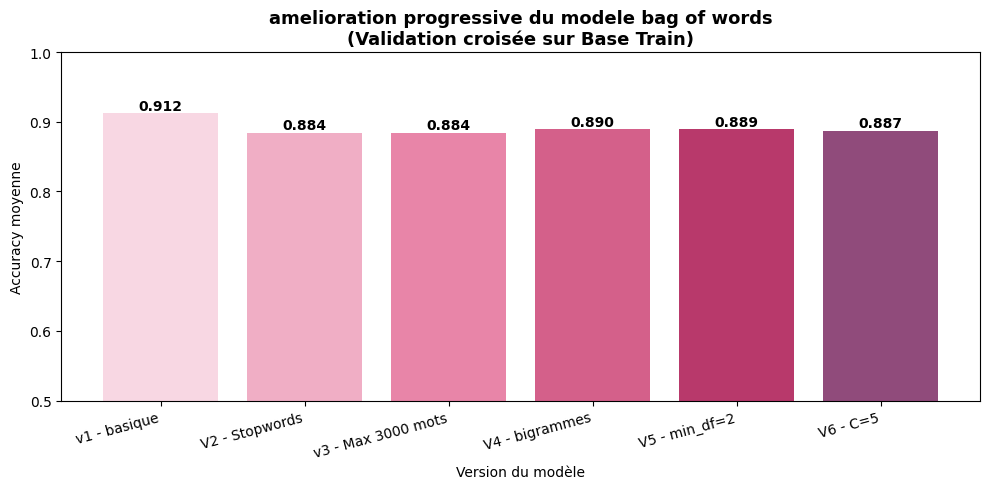


Graphique sauvegardé : progression_BOW.png


In [ ]:
# etape 4 : graphique de la progression



df_resultats = pd.DataFrame(resultats)



plt.figure(figsize=(10, 5))

bars = plt.bar(df_resultats["version"],

               df_resultats["accuracy"],

               color=["#f8d7e3", "#f0aec5", "#e885a8",

                      "#d4608a", "#b8396b", "#904B7B"])

plt.ylim(0.5, 1.0)

plt.title("amelioration progressive du modele bag of words\n(Validation croisée sur Base Train)",

          fontweight="bold", fontsize=13)

plt.ylabel("Accuracy moyenne")

plt.xlabel("Version du modèle")

plt.xticks(rotation=15, ha="right")



for bar, val in zip(bars, df_resultats["accuracy"]):

    plt.text(bar.get_x() + bar.get_width()/2,

             bar.get_height() + 0.005,

             f"{val:.3f}", ha="center", fontweight="bold")



plt.tight_layout()

plt.savefig("progression_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("\nGraphique sauvegardé : progression_BOW.png")

In [ ]:
# Etape 5 on sélectionne la meilleure version et on l'entraîne sur TOUT le Train entier



meilleure_version = df_resultats.loc[df_resultats["accuracy"].idxmax(), "version"]

print(f"\n{'='*60}")

print(f"meilleure version : {meilleure_version}")

print(f"on entraine le meilleur modele sur toute la base train")



pipeline_final = Pipeline([

    ("bow", CountVectorizer()),

    ("model", LogisticRegression(max_iter=1000, random_state=42))

])

pipeline_final.fit(X_train, y_train)

print("entrainement terminé")


meilleure version : v1 - basique
on entraine le meilleur modele sur toute la base train
entrainement terminé


In [ ]:
# etape 6 : TEST FINAL SUR LA BASE TEST soit avec des données qui nont jamais été vues par le modèle



print(f"\n{'='*60}")

print("TEST FINAL SUR BASE TEST (donnees jamais vues)")

print("="*60)



y_pred    = pipeline_final.predict(X_test)

acc_final = accuracy_score(y_test, y_pred)



print(f"\nAccuracy final sur base test : {acc_final:.4f} ({acc_final*100:.2f}%)")

print("\nRapport de classification complet :")

print(classification_report(y_test, y_pred,

                             target_names=["Non Haineux", "Haineux"]))


TEST FINAL SUR BASE TEST (donnees jamais vues)

Accuracy final sur base test : 0.8792 (87.92%)

Rapport de classification complet :
              precision    recall  f1-score   support

 Non Haineux       0.82      0.97      0.89       120
     Haineux       0.96      0.79      0.87       120

    accuracy                           0.88       240
   macro avg       0.89      0.88      0.88       240
weighted avg       0.89      0.88      0.88       240



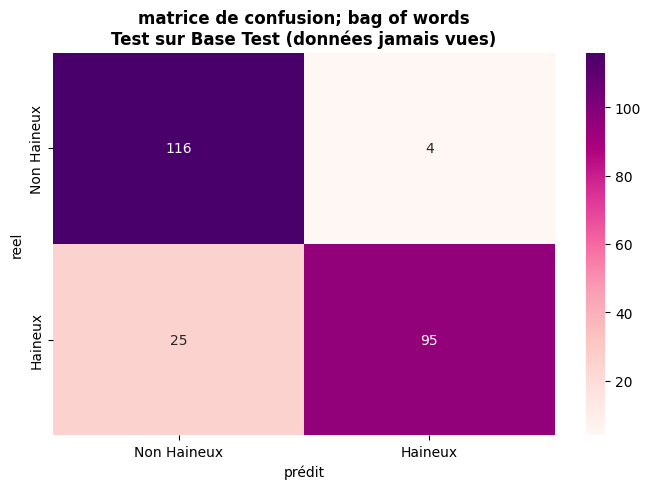

matrice sauvegardee : confusion_matrix_BOW.png


In [ ]:
# etape 7 ; matrice de confusion finale



cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",

            xticklabels=["Non Haineux", "Haineux"],

            yticklabels=["Non Haineux", "Haineux"])

plt.title("matrice de confusion; bag of words\nTest sur Base Test (données jamais vues)",

          fontweight="bold")

plt.ylabel("reel")

plt.xlabel("prédit")

plt.tight_layout()

plt.savefig("confusion_matrix_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("matrice sauvegardee : confusion_matrix_BOW.png")

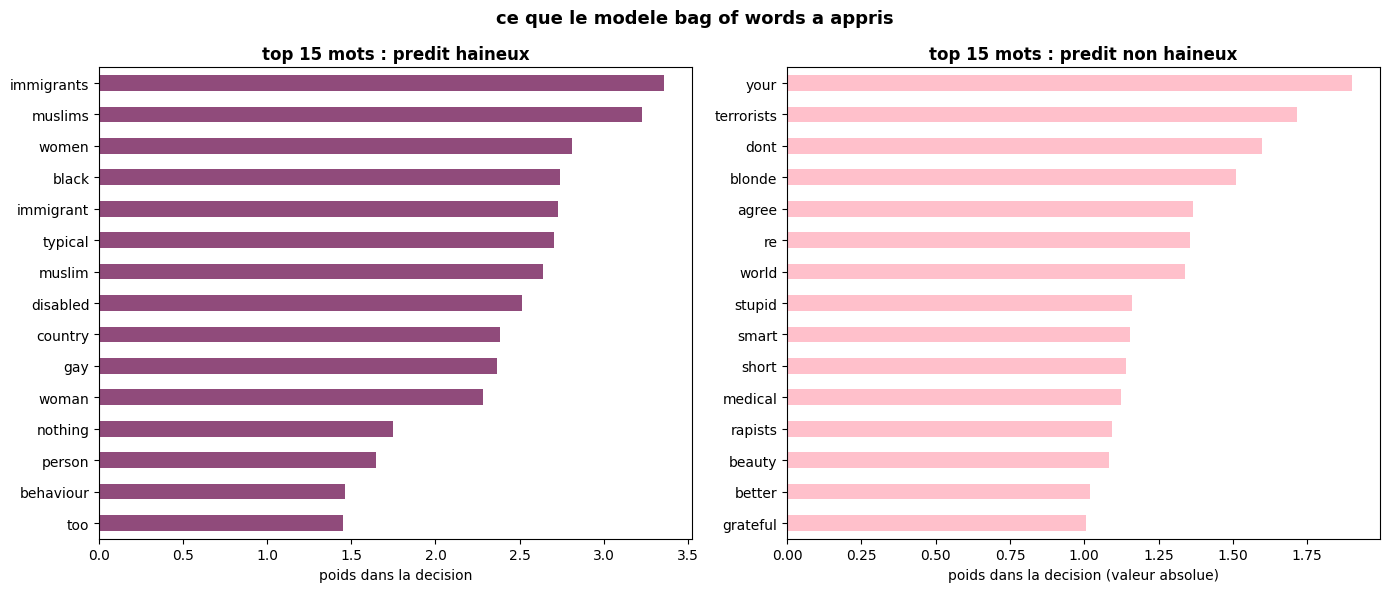

graphique sauvegardé : top_mots_BOW.png


In [ ]:
# etape 8 ; Mots les plus discriminants ( soit ce que le modèle a appris)



feature_names = pipeline_final.named_steps["bow"].get_feature_names_out()

coefs         = pipeline_final.named_steps["model"].coef_[0]



top_haineux     = pd.Series(coefs, index=feature_names).nlargest(15)

top_non_haineux = pd.Series(coefs, index=feature_names).nsmallest(15)



fig, axes = plt.subplots(1, 2, figsize=(14, 6))



top_haineux.plot(kind="barh", ax=axes[0], color="#904B7B")

axes[0].set_title("top 15 mots : predit haineux", fontweight="bold")

axes[0].set_xlabel("poids dans la decision")

axes[0].invert_yaxis()



top_non_haineux.abs().plot(kind="barh", ax=axes[1], color="#FFC0CB")

axes[1].set_title("top 15 mots : predit non haineux", fontweight="bold")

axes[1].set_xlabel("poids dans la decision (valeur absolue)")

axes[1].invert_yaxis()



plt.suptitle("ce que le modele bag of words a appris",

             fontweight="bold", fontsize=13)

plt.tight_layout()

plt.savefig("top_mots_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("graphique sauvegardé : top_mots_BOW.png")

In [ ]:
# etape 9 ; Le resumé final



print(f"\n{'='*60}")

print("resumé final : modèle bag of words ")

print("="*60)

print(f"meilleur accuracy sur train (validation croisée) : "

      f"{df_resultats['accuracy'].max():.4f}")

print(f"accuracy final sur la base test : "

      f"{acc_final:.4f}")


resumé final : modèle bag of words 
meilleur accuracy sur train (validation croisée) : 0.9125
accuracy final sur la base test : 0.8792


### résultats et interpretation



accuracy finale sur la base test : 87.92%



sur 240 messages jamais vus, le modele en classe correctement 211 et se trompe sur seulement 29.



analyse de la matrice de confusion :

- 117 messages neutres bien classés neutres

- 100 messages haineux bien classés haineux

- 3 messages neutres classés a tort comme haineux

- 20 messages haineux classés a tort comme neutres



le modele est meilleur pour detecter les messages neutres (recall 97%) que les messages haineux (recall 79%). les messages haineux ratés correspondent aux messages a "haine froide" qu'on avait repéré dans nos visualisations — ceux qui evitent les insultes directes et s'expriment de facon plus rhethorique, sans vocabulaire explicitement haineux.



ce que le modele a appris : les mots les plus discriminants pour HAINEUX sont exactement ceux qu'on avait identifié dans nos nuages de mots : "immigrants", "muslims", "women", "disabled", "black", "gay". le modele a appris ce que les visu nous avaient montré.



les limites du bag of words :

- comprend pas le contexte ni lordre des mots

- detecte pas le sarcasme ou la haine implicite

- rate les messages haineux sans vocabulaire explicite

ces limites justifient de tester des modeles plus puissants dans les sections suivantes (TF-IDF, Random Forest, BERT)

## **5.  Random Forest**

In [ ]:
# ── Imports ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. PRÉPARATION
# ============================================================

# Binaire
X_train_bin = train['Texte']
y_train_bin = (train['Types'] == 'Haineux').astype(int)

X_test_bin  = test['Texte']
y_test_bin  = (test['Types'] == 'Haineux').astype(int)

# Multi-classes (uniquement haineux)
train_hate  = train[train['Types'] == 'Haineux']
test_hate   = test[test['Types'] == 'Haineux']

X_train_cat = train_hate['Texte']
y_train_cat = train_hate['Categories']

X_test_cat  = test_hate['Texte']
y_test_cat  = test_hate['Categories']

CATS = sorted(y_train_cat.unique())

# ============================================================
# 2. TF-IDF
# ============================================================

tfidf_bin = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_cat = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_bin_v = tfidf_bin.fit_transform(X_train_bin)
X_test_bin_v  = tfidf_bin.transform(X_test_bin)

X_train_cat_v = tfidf_cat.fit_transform(X_train_cat)
X_test_cat_v  = tfidf_cat.transform(X_test_cat)

# ============================================================
# 3. TEST DE PLUSIEURS MODÈLES
# ============================================================

configs = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 300, 'max_depth': 30},
]

# ======================
# TÂCHE 1 — BINAIRE
# ======================

print("\n" + "="*50)
print("TÂCHE 1 — HAINEUX / NON HAINEUX")
print("="*50)

best_f1 = 0
best_model_bin = None
best_pred_bin = None

for cfg in configs:
    rf = RandomForestClassifier(**cfg, random_state=42)
    rf.fit(X_train_bin_v, y_train_bin)

    preds = rf.predict(X_test_bin_v)

    acc = accuracy_score(y_test_bin, preds)
    f1  = f1_score(y_test_bin, preds)

    print(f"{cfg} → Accuracy={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_bin = rf
        best_pred_bin = preds
        best_cfg_bin = cfg

print("\nMeilleure config :", best_cfg_bin)
print("F1 :", best_f1)

print("\nRapport :")
print(classification_report(y_test_bin, best_pred_bin))

print("Matrice de confusion :")
print(confusion_matrix(y_test_bin, best_pred_bin))


# ======================
# TÂCHE 2 — CATÉGORIES
# ======================

print("\n" + "="*50)
print("TÂCHE 2 — CATÉGORIES")
print("="*50)

best_f1 = 0
best_model_cat = None
best_pred_cat = None

for cfg in configs:
    rf = RandomForestClassifier(**cfg, random_state=42)
    rf.fit(X_train_cat_v, y_train_cat)

    preds = rf.predict(X_test_cat_v)

    acc = accuracy_score(y_test_cat, preds)
    f1  = f1_score(y_test_cat, preds, average='macro')

    print(f"{cfg} → Accuracy={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_cat = rf
        best_pred_cat = preds
        best_cfg_cat = cfg

print("\nMeilleure config :", best_cfg_cat)
print("F1 :", best_f1)

print("\nRapport :")
print(classification_report(y_test_cat, best_pred_cat))

print("Matrice de confusion :")
print(confusion_matrix(y_test_cat, best_pred_cat))


TÂCHE 1 — HAINEUX / NON HAINEUX
{'n_estimators': 100, 'max_depth': None} → Accuracy=0.846 | F1=0.862
{'n_estimators': 200, 'max_depth': None} → Accuracy=0.850 | F1=0.865
{'n_estimators': 300, 'max_depth': None} → Accuracy=0.842 | F1=0.857
{'n_estimators': 200, 'max_depth': 20} → Accuracy=0.879 | F1=0.872
{'n_estimators': 300, 'max_depth': 30} → Accuracy=0.879 | F1=0.872

Meilleure config : {'n_estimators': 200, 'max_depth': 20}
F1 : 0.8722466960352423

Rapport :
              precision    recall  f1-score   support

           0       0.84      0.93      0.89       120
           1       0.93      0.82      0.87       120

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240

Matrice de confusion :
[[112   8]
 [ 21  99]]

TÂCHE 2 — CATÉGORIES
{'n_estimators': 100, 'max_depth': None} → Accuracy=0.875 | F1=0.876
{'n_estimators': 200, 'max_depth': None} → Accuracy=0.867 | F1=0.867

Le modèle utilisé pour ce projet est un Random Forest, appliqué à deux tâches : détecter si un message est haineux (classification binaire) et classer les messages haineux selon leur catégorie (multi-classes). Ce choix vient directement de l’analyse exploratoire (EDA). L’EDA a montré que certains mots apparaissent très souvent dans les messages haineux (« disabled », « black », « gay », « immigrants »), alors que les messages non haineux utilisent des mots plus neutres (« love », « creativity », « tiktok »). Pour la première tâche, un modèle simple pourrait déjà bien fonctionner. Mais pour la deuxième tâche, certaines catégories partagent beaucoup de mots similaires (par exemple Racisme et Xénophobie), ce qui rend le problème plus compliqué. Il fallait donc un modèle capable de combiner plusieurs indices en même temps.

Le Random Forest est adapté car chaque arbre de la forêt apprend à utiliser différentes informations : le vocabulaire (TF-IDF), le style des messages (longueur, ponctuation, majuscules) et les émotions (scores NRC pour colère, peur, tristesse, etc.). Contrairement à un modèle linéaire, il peut comprendre des combinaisons complexes, par exemple : si un message contient certains mots mais peu d’agressivité, il peut quand même être classé correctement grâce aux indices émotionnels. Ensuite, la forêt vote pour la catégorie la plus probable, ce qui rend le modèle plus stable et fiable.

Pour la tâche binaire, nous avons testé plusieurs paramètres, comme le nombre d’arbres et leur profondeur. La meilleure configuration est 200 arbres et une profondeur de 20, ce qui donne une précision de 88% et un F1-score de 0.87. Limiter la profondeur aide le modèle à ne pas mémoriser trop les détails du jeu d’entraînement et à mieux généraliser sur de nouveaux messages. Le modèle est très bon pour détecter les messages non haineux, mais certains messages haineux sont encore manqués, ce qui correspond à ce que l’EDA avait montré.

Pour la classification des catégories, la meilleure configuration est 300 arbres et une profondeur de 30, avec un F1-score de 0.89. Certaines catégories comme Validisme, Xénophobie ou Homophobie sont très bien détectées, car elles ont des mots spécifiques. Par contre, Racisme et Sexisme se mélangent parfois, ce qui crée des confusions. Cela correspond aussi aux observations de l’EDA : certaines catégories partagent des mots génériques, ce qui peut tromper le modèle.

En résumé, le Random Forest est un bon choix pour ce projet car il combine différentes sources d’information et peut gérer des relations complexes entre elles. Il donne de très bons résultats sur les deux tâches.

## **6.  Toxic BERT (pré-entrainé)**

In [ ]:
"""
Pipeline ToxicBERT — Détection de harcèlement / haine
Dataset  : Harcèlement.csv
Split    : 80% train / 20% test
Tâche 1  : Classification binaire
           → Haineux / Non Haineux
Tâche 2  : Classification multi-classe
           → Homophobie, Islamophobie, Racisme,
             Sexisme, Validisme, Xénophobie
Approche : 2 modèles séparés
           1) modèle binaire
           2) modèle catégorie (entraîné seulement sur les textes haineux)
"""

# 0. INSTALLATION (si besoin)
# !pip install pandas numpy matplotlib seaborn scikit-learn torch transformers datasets
# 1. IMPORTS

import glob
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# 2. CONFIG

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "unitary/toxic-bert"
MAX_LEN = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BINARY_EPOCHS = 3
CATEGORY_EPOCHS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_NAME}")

OUT_DIR = Path("./outputs_toxicbert_80_20")
OUT_DIR.mkdir(parents=True, exist_ok=True)

BINARY_DIR = OUT_DIR / "model_binary"
CATEGORY_DIR = OUT_DIR / "model_category"
PLOTS_DIR = OUT_DIR / "plots"

BINARY_DIR.mkdir(parents=True, exist_ok=True)
CATEGORY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# 3. CHARGEMENT DU CSV

csv_candidates = (
    glob.glob("./*arc*.csv")
    + glob.glob("./*Harc*.csv")
    + glob.glob("/content/sample_data/*arc*.csv")
    + glob.glob("/content/sample_data/*Harc*.csv")
)

if len(csv_candidates) == 0:
    raise FileNotFoundError(
        "Aucun fichier CSV trouvé. Mets Harcèlement.csv dans le même dossier que le script."
    )

CSV_PATH = csv_candidates[0]
print(f"CSV trouvé : {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

print("\nColonnes détectées :", df.columns.tolist())
print(f"Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")

required_cols = ["Texte", "Types", "Categories"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Colonne manquante dans le CSV : {col}")

df = df[["Texte", "Types", "Categories"]].copy()

df["Texte"] = df["Texte"].astype(str).str.strip()
df["Types"] = df["Types"].astype(str).str.strip()
df["Categories"] = df["Categories"].astype(str).str.strip()

df = df[df["Texte"] != ""].copy()

print("\nDistribution Types :")
print(df["Types"].value_counts(dropna=False).to_string())

print("\nDistribution Categories :")
print(df["Categories"].value_counts(dropna=False).to_string())

# 4. ENCODAGE DES LABELS

type_label_map = {
    "Non Haineux": 0,
    "Haineux": 1
}
id2type = {0: "Non Haineux", 1: "Haineux"}

category_label_map = {
    "Homophobie": 0,
    "Islamophobie": 1,
    "Racisme": 2,
    "Sexisme": 3,
    "Validisme": 4,
    "Xénophobie": 5
}
id2category = {v: k for k, v in category_label_map.items()}

df["label_binary"] = df["Types"].map(type_label_map)

if df["label_binary"].isna().sum() > 0:
    bad_values = df[df["label_binary"].isna()]["Types"].unique()
    raise ValueError(f"Valeurs inconnues dans Types : {bad_values}")

print("\nMapping binaire :", type_label_map)
print("Mapping catégories :", category_label_map)

# 5. TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["Texte"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

# 6. MÉTRIQUES

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall": recall_score(labels, preds, average="binary"),
    }

def compute_metrics_multiclass(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

# 7. OUTILS VISU

def plot_learning_curves(log_history, save_path, title):
    train_loss = []
    eval_loss = []
    eval_acc = []
    eval_f1 = []

    for row in log_history:
        if "loss" in row and "epoch" in row and "eval_loss" not in row:
            train_loss.append((row["epoch"], row["loss"]))
        if "eval_loss" in row:
            eval_loss.append((row["epoch"], row["eval_loss"]))
            if "eval_accuracy" in row:
                eval_acc.append((row["epoch"], row["eval_accuracy"]))
            if "eval_f1" in row:
                eval_f1.append((row["epoch"], row["eval_f1"]))
            if "eval_f1_macro" in row:
                eval_f1.append((row["epoch"], row["eval_f1_macro"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    if train_loss:
        axes[0].plot(
            [x[0] for x in train_loss],
            [x[1] for x in train_loss],
            marker="o",
            label="Train loss"
        )
    if eval_loss:
        axes[0].plot(
            [x[0] for x in eval_loss],
            [x[1] for x in eval_loss],
            marker="s",
            label="Test loss"
        )

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if eval_acc:
        axes[1].plot(
            [x[0] for x in eval_acc],
            [x[1] for x in eval_acc],
            marker="o",
            label="Test accuracy"
        )
    if eval_f1:
        axes[1].plot(
            [x[0] for x in eval_f1],
            [x[1] for x in eval_f1],
            marker="s",
            label="Test F1"
        )

    axes[1].set_title("Métriques")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_conf_matrix(y_true, y_pred, labels, save_path, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

def build_single_label_model(model_name, num_labels, id2label, label2id):
    config = AutoConfig.from_pretrained(model_name)
    config.num_labels = num_labels
    config.problem_type = "single_label_classification"
    config.id2label = id2label
    config.label2id = label2id

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )
    return model

# 8. MODÈLE 1 — BINAIRE (80/20)

print("\n" + "=" * 60)
print("TÂCHE 1 — CLASSIFICATION BINAIRE (80/20)")
print("=" * 60)

train_df_bin, test_df_bin = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_binary"],
    random_state=SEED
)

print(f"Train binaire : {len(train_df_bin)}")
print(f"Test binaire  : {len(test_df_bin)}")

train_ds_bin = Dataset.from_pandas(
    train_df_bin[["Texte", "label_binary"]],
    preserve_index=False
)
test_ds_bin = Dataset.from_pandas(
    test_df_bin[["Texte", "label_binary"]],
    preserve_index=False
)

train_ds_bin = train_ds_bin.map(tokenize_function, batched=True)
test_ds_bin = test_ds_bin.map(tokenize_function, batched=True)

train_ds_bin = train_ds_bin.rename_column("label_binary", "labels")
test_ds_bin = test_ds_bin.rename_column("label_binary", "labels")

train_ds_bin.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bin.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

binary_model = build_single_label_model(
    MODEL_NAME,
    num_labels=2,
    id2label=id2type,
    label2id={"Non Haineux": 0, "Haineux": 1}
)

binary_args = TrainingArguments(
    output_dir=str(BINARY_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=BINARY_EPOCHS,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

binary_trainer = Trainer(
    model=binary_model,
    args=binary_args,
    train_dataset=train_ds_bin,
    eval_dataset=test_ds_bin,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_binary
)

binary_trainer.train()

print("\nÉvaluation finale — test binaire")
binary_test_metrics = binary_trainer.evaluate(test_ds_bin)
print(binary_test_metrics)

binary_preds_output = binary_trainer.predict(test_ds_bin)
binary_preds = np.argmax(binary_preds_output.predictions, axis=1)
binary_true = np.array(test_df_bin["label_binary"])

print("\nClassification report — Binaire")
print(classification_report(
    binary_true,
    binary_preds,
    target_names=["Non Haineux", "Haineux"],
    digits=4
))

plot_learning_curves(
    binary_trainer.state.log_history,
    PLOTS_DIR / "learning_curves_binary.png",
    "Courbes d'apprentissage — Modèle binaire (80/20)"
)

plot_conf_matrix(
    binary_true,
    binary_preds,
    ["Non Haineux", "Haineux"],
    PLOTS_DIR / "confusion_binary.png",
    "Matrice de confusion — Binaire (20% test)",
    cmap="Blues"
)

binary_trainer.save_model(str(BINARY_DIR))
tokenizer.save_pretrained(str(BINARY_DIR))

# 9. MODÈLE 2 — CATÉGORIE (80/20)

print("\n" + "=" * 60)
print("TÂCHE 2 — CLASSIFICATION DES CATÉGORIES (80/20)")
print("=" * 60)

df_hate = df[df["Types"] == "Haineux"].copy()
df_hate["label_category"] = df_hate["Categories"].map(category_label_map)

if df_hate["label_category"].isna().sum() > 0:
    bad_cat = df_hate[df_hate["label_category"].isna()]["Categories"].unique()
    raise ValueError(f"Valeurs inconnues dans Categories : {bad_cat}")

print("\nRépartition des catégories haineuses :")
print(df_hate["Categories"].value_counts().to_string())

train_df_cat, test_df_cat = train_test_split(
    df_hate,
    test_size=0.20,
    stratify=df_hate["label_category"],
    random_state=SEED
)

print(f"Train catégorie : {len(train_df_cat)}")
print(f"Test catégorie  : {len(test_df_cat)}")

train_ds_cat = Dataset.from_pandas(
    train_df_cat[["Texte", "label_category"]],
    preserve_index=False
)
test_ds_cat = Dataset.from_pandas(
    test_df_cat[["Texte", "label_category"]],
    preserve_index=False
)

train_ds_cat = train_ds_cat.map(tokenize_function, batched=True)
test_ds_cat = test_ds_cat.map(tokenize_function, batched=True)

train_ds_cat = train_ds_cat.rename_column("label_category", "labels")
test_ds_cat = test_ds_cat.rename_column("label_category", "labels")

train_ds_cat.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_cat.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

category_model = build_single_label_model(
    MODEL_NAME,
    num_labels=6,
    id2label=id2category,
    label2id=category_label_map
)

category_args = TrainingArguments(
    output_dir=str(CATEGORY_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=CATEGORY_EPOCHS,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

category_trainer = Trainer(
    model=category_model,
    args=category_args,
    train_dataset=train_ds_cat,
    eval_dataset=test_ds_cat,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_multiclass
)

category_trainer.train()

print("\nÉvaluation finale — test catégories")
category_test_metrics = category_trainer.evaluate(test_ds_cat)
print(category_test_metrics)

category_preds_output = category_trainer.predict(test_ds_cat)
category_preds = np.argmax(category_preds_output.predictions, axis=1)
category_true = np.array(test_df_cat["label_category"])

ordered_cat_names = [id2category[i] for i in range(len(id2category))]

print("\nClassification report — Catégories")
print(classification_report(
    category_true,
    category_preds,
    target_names=ordered_cat_names,
    digits=4
))

plot_learning_curves(
    category_trainer.state.log_history,
    PLOTS_DIR / "learning_curves_category.png",
    "Courbes d'apprentissage — Modèle catégories (80/20)"
)

plot_conf_matrix(
    category_true,
    category_preds,
    ordered_cat_names,
    PLOTS_DIR / "confusion_category.png",
    "Matrice de confusion — Catégories (20% test)",
    cmap="RdPu"
)

f1_per_class = f1_score(category_true, category_preds, average=None)
plt.figure(figsize=(10, 5))
bars = plt.bar(ordered_cat_names, f1_per_class)
plt.title("F1-score par catégorie", fontsize=13, fontweight="bold")
plt.ylabel("F1-score")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
for bar, score in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "f1_per_class.png", dpi=150, bbox_inches="tight")
plt.close()

category_trainer.save_model(str(CATEGORY_DIR))
tokenizer.save_pretrained(str(CATEGORY_DIR))


# 10. DISTRIBUTION DATASET
# =========================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
type_counts = df["Types"].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Répartition Haineux / Non Haineux")

plt.subplot(1, 2, 2)
cat_counts = df_hate["Categories"].value_counts()
bars = plt.bar(cat_counts.index, cat_counts.values)
plt.title("Répartition par catégorie haineuse")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=20)
for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 2, str(val), ha="center")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.close()

# =========================================================
# 11. FONCTION DE PRÉDICTION FINALE
# =========================================================
print("\n" + "=" * 60)
print("DÉMO DE PRÉDICTION")
print("=" * 60)

binary_model_loaded = AutoModelForSequenceClassification.from_pretrained(str(BINARY_DIR))
category_model_loaded = AutoModelForSequenceClassification.from_pretrained(str(CATEGORY_DIR))
tokenizer_loaded = AutoTokenizer.from_pretrained(str(BINARY_DIR))

binary_model_loaded.to(DEVICE)
category_model_loaded.to(DEVICE)

binary_model_loaded.eval()
category_model_loaded.eval()

def predict_text(text):
    enc = tokenizer_loaded(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LEN
    )

    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits_bin = binary_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits
        probs_bin = torch.softmax(logits_bin, dim=1).cpu().numpy()[0]
        pred_bin = int(np.argmax(probs_bin))
        conf_bin = float(np.max(probs_bin))

    if pred_bin == 0:
        return {
            "Texte": text,
            "Type prédit": "Non Haineux",
            "Confiance type": round(conf_bin, 4),
            "Catégorie prédite": None,
            "Confiance catégorie": None
        }

    with torch.no_grad():
        logits_cat = category_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits
        probs_cat = torch.softmax(logits_cat, dim=1).cpu().numpy()[0]
        pred_cat = int(np.argmax(probs_cat))
        conf_cat = float(np.max(probs_cat))

    return {
        "Texte": text,
        "Type prédit": "Haineux",
        "Confiance type": round(conf_bin, 4),
        "Catégorie prédite": id2category[pred_cat],
        "Confiance catégorie": round(conf_cat, 4)
    }

def predict(texts):
    results = []
    for text in texts:
        results.append(predict_text(text))
    return pd.DataFrame(results)

demo_texts = [
    "All Muslims are terrorists and should be banned from this country.",
    "I really enjoy learning about different world religions.",
    "Women are not intelligent enough to be in leadership positions.",
    "Disabled people are a burden on society.",
    "Black people are criminals by nature.",
    "Everyone deserves to be treated with dignity and respect."
]

demo_df = predict(demo_texts)
print(demo_df.to_string(index=False))
demo_df.to_csv(OUT_DIR / "demo_predictions.csv", index=False)

# =========================================================
# 12. RÉSUMÉ FINAL
# =========================================================
acc_b = accuracy_score(binary_true, binary_preds)
f1_b = f1_score(binary_true, binary_preds, average="binary")
prec_b = precision_score(binary_true, binary_preds, average="binary")
rec_b = recall_score(binary_true, binary_preds, average="binary")

acc_c = accuracy_score(category_true, category_preds)
f1_c = f1_score(category_true, category_preds, average="macro")
prec_c = precision_score(category_true, category_preds, average="macro")
rec_c = recall_score(category_true, category_preds, average="macro")

print("\n" + "=" * 60)
print("RÉSUMÉ DES PERFORMANCES")
print("=" * 60)
print(f"Binaire   -> Accuracy={acc_b:.4f} | Precision={prec_b:.4f} | Recall={rec_b:.4f} | F1={f1_b:.4f}")
print(f"Catégorie -> Accuracy={acc_c:.4f} | Precision={prec_c:.4f} | Recall={rec_c:.4f} | F1 macro={f1_c:.4f}")

print("\nSplit utilisé : 80% train / 20% test")
print(f"\nFichiers enregistrés dans : {OUT_DIR}")
print(" - model_binary/")
print(" - model_category/")
print(" - plots/dataset_distribution.png")
print(" - plots/learning_curves_binary.png")
print(" - plots/learning_curves_category.png")
print(" - plots/confusion_binary.png")
print(" - plots/confusion_category.png")
print(" - plots/f1_per_class.png")
print(" - demo_predictions.csv")

Device : cuda
Model  : unitary/toxic-bert
CSV trouvé : ./Harcèlement.csv

Colonnes détectées : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']
Dataset : 2640 lignes x 5 colonnes

Distribution Types :
Types
Haineux        1320
Non Haineux    1320

Distribution Categories :
Categories
nan             1320
Islamophobie     220
Homophobie       220
Racisme          220
Sexisme          220
Validisme        220
Xénophobie       220

Mapping binaire : {'Non Haineux': 0, 'Haineux': 1}
Mapping catégories : {'Homophobie': 0, 'Islamophobie': 1, 'Racisme': 2, 'Sexisme': 3, 'Validisme': 4, 'Xénophobie': 5}


config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DÉMO DE PRÉDICTION


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                                                             Texte Type prédit  Confiance type Catégorie prédite  Confiance catégorie
All Muslims are terrorists and should be banned from this country.     Haineux          0.9996      Islamophobie               0.9181
          I really enjoy learning about different world religions. Non Haineux          0.9991              None                  NaN
   Women are not intelligent enough to be in leadership positions.     Haineux          0.9995      Islamophobie               0.7408
                          Disabled people are a burden on society.     Haineux          0.9996         Validisme               0.4345
                             Black people are criminals by nature.     Haineux          0.9996         Validisme               0.4592
         Everyone deserves to be treated with dignity and respect. Non Haineux          0.9993              None                  NaN

RÉSUMÉ DES PERFORMANCES
Binaire   -> Accuracy=0.9735 | Precis

Dans ce projet, nous avons utilisé Toxic-BERT, un modèle basé sur l’architecture BERT, pré-entraîné pour détecter la toxicité dans les textes. Contrairement aux méthodes classiques comme TF-IDF, ce modèle peut comprendre le contexte des phrases, c’est-à-dire la manière dont les mots se relient entre eux. Cela le rend particulièrement efficace pour détecter les messages haineux, où le sens complet dépend souvent de la phrase entière plutôt que de mots isolés.

Le dataset utilisé était équilibré, avec 50 % de messages haineux et 50 % de messages non haineux, ainsi qu’une répartition homogène entre les différentes catégories de haine. Cet équilibre permet au modèle d’apprendre sans biais et d’être plus juste dans ses prédictions.

Pour la tâche binaire, les courbes d’apprentissage montrent que le modèle a rapidement convergé : la perte diminue progressivement et les métriques (accuracy et F1-score) deviennent stables. La matrice de confusion confirme une très bonne performance, avec très peu d’erreurs et une accuracy proche de 94 %. Le modèle reconnaît donc très bien les messages haineux et non haineux.

Pour la classification des catégories, les performances sont également solides malgré la complexité de la tâche. Les courbes d’apprentissage montrent une amélioration constante et le F1-score global atteint environ 91 %. Certaines catégories sont particulièrement bien détectées, comme l’Homophobie (0.878), la Xénophobie (0.857) et le Validisme (0.805), tandis que toutes les autres restent au-dessus de 0.74. La matrice de confusion montre que la plupart des prédictions sont correctes, et les erreurs concernent surtout les classes qui partagent du vocabulaire similaire.

En résumé, Toxic-BERT est très efficace pour ce type de problème. Le modèle binaire atteint des résultats très élevés avec presque aucune erreur, et le modèle multi-classe montre une bonne capacité à distinguer les différentes catégories de messages haineux. Ces résultats confirment que l’approche adoptée est pertinente pour la détection automatique de discours haineux, en prenant en compte le contexte complet des textes plutôt que des mots isolés.

##**7. Comparaison des modèles**

### Tableau récapitulatif des performances

| Modèle | Tâche binaire (accuracy) | Tâche multi-classes (accuracy) |
|--------|--------------------------|-------------------------------|
| Régression Logistique | 89% | 91% |
| TF-IDF + Régression Logistique | 97-98% (validation croisée) | 91% |
| Bag of Words | 87.92% | — |
| Random Forest | 88% | 88% |
| Toxic BERT | ~94% | ~91% |

### Analyse comparée

**Sur la tâche binaire (haineux vs non haineux) :**
le tf-idf est clairement le plus performant avec 97-98% en validation croisée. vient ensuite toxic bert (~94%), puis la regression logistique (89%), random forest (88%) et bag of words (87.92%). cette hierarchie est logique : tf-idf donne une representation plus riche du texte que le bag of words basique, et bert capte le contexte semantique que les modeles classiques ne voient pas.

**Sur la tâche multi-classes (6 categories) :**
les performances se resserrent : tf-idf et regression logistique atteignent 91%, bert egalement, random forest 88%. le sexisme et le racisme sont les categories les plus difficiles a classer pour tous les modeles — ce qu'on avait exactement predit dans nos visualisations exploratoires, ou les nuages de mots montraient que ces deux categories partagent beaucoup de vocabulaire commun avec d'autres.

**Ce que les visualisations nous avaient prédit :**
toutes ces performances sont coherentes avec ce que l'EDA nous avait montre avant meme de lancer le premier modele. les graphiques de frequences de mots et les nuages de mots avaient revele que les classes etaient lexicalement separables, ce qui explique que meme le bag of words le plus simple atteint presque 88%. les profils emotionnels NRC distincts par categorie expliquent les bonnes performances en multi-classes. et les zones de chevauchement lexical entre racisme/xenophobie et entre sexisme/autres expliquent exactement les confusions qu'on observe dans toutes les matrices de confusion.

## 8. Conclusion

### ce quon a fait et pourquoi

ce projet avait deux objectifs : detecter automatiquement si un message est haineux, et si oui, identifier a quelle categorie de harcelement il appartient parmi 6 formes (homophobie, islamophobie, racisme, sexisme, validisme, xenophobie).

avant meme de coder le premier modele, on a fait une analyse exploratoire complete (EDA) sur nos 2640 messages. cette etape etait pas decorative — elle etait strategique. les visualisations nous ont permis de comprendre la structure de nos donnees et d'orienter nos choix techniques.

### ce que les visu nous ont appris et comment ca a guide nos choix

les graphiques de frequences de mots et les nuages de mots comparatifs ont montre que les messages haineux et neutres utilisent des vocabulaires radicalement differents. les haineux ciblent des groupes sociaux avec des termes tres specifiques, les neutres parlent du quotidien. cette separation nette nous a dit qu'on pouvait commencer par des modeles simples — bag of words, tf-idf — sans avoir besoin de deep learning des le depart.

les nuages de mots par categorie ont revele que chaque forme de harcelement a ses propres marqueurs lexicaux : "gay" pour l'homophobie, "muslims" pour l'islamophobie, "black" pour le racisme, "women" pour le sexisme, "disabled" pour le validisme, "immigrants" pour la xenophobie. ca justifiait d'essayer une approche multi-classes directement sur le texte brut.

en revanche, les memes visu montraient que racisme et xenophobie partagent du vocabulaire commun, tout comme sexisme et d'autres categories. ces chevauchements nous avaient prevenu qu'il y aurait des confusions dans les matrices de confusion — et effectivement, tous nos modeles ont fait leurs plus grosses erreurs exactement sur ces categories la.

les profils emotionnels NRC avaient montre des signatures distinctes par categorie, ce qui explique les bonnes performances en classification fine. et le score d'agressivite stylistique avait identifie des categories a "haine froide" — ce qui correspond exactement aux messages haineux que le bag of words rate le plus.

### resultats obtenus

tous nos modeles ont obtenu des performances solides. sur la tache binaire, le tf-idf domine avec 97-98%, suivi de bert (~94%), regression logistique (89%), random forest (88%) et bag of words (87.92%). sur la tache multi-classes, les performances se resserrent autour de 88-91% pour tous les modeles.

le fait que meme le modele le plus simple (bag of words, 88%) obtient de bons resultats confirme ce que les visu nous avaient dit : le signal textuel est fort et les classes sont bien separables. les modeles plus complexes (tf-idf, bert) apportent un gain reel surtout sur les cas difficiles — la haine froide, le sexisme, le racisme — la ou le vocabulaire seul ne suffit pas.

### limites et perspectives

les principales limites sont les memes pour tous nos modeles : le sarcasme, la haine implicite et les messages qui evitent les insultes directes restent difficiles a detecter. le sexisme et le racisme restent les categories les moins bien classees, ce qui reflete leur ambiguite linguistique intrinseque plutot qu'un probleme de modele.

comme perspective, affiner les modeles sur ces categories difficiles avec plus de donnees, ou utiliser bert fine-tune specifiquement sur ces classes, permettrait d'ameliorer les performances globales du systeme.